# case study: GI

In [1]:
from utils_WF import *
from utils_GI import *

/Users/markzhao/miniconda3/envs/network/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.4.0' currently installed).
  from pandas.core import (


In [2]:
# read from GI-data

# labels (open reading frames) of the essential genes
genes = np.loadtxt('GI-data/genes.txt', dtype=str)

# raw GI network of the essential genes (query vs array)
E = np.load('GI-data/E.npy')

# edge-level noise variance of the raw GI network of the essential genes (query vs array)
E_var = np.load('GI-data/E_var.npy')

In [3]:
# run the netWF algorithm to get the filtered GI network E_filtered

E_filtered = wiener_filter_iterative(E, E_var, directed=False, epsilon = 1e-2,
                                     solver='cg', rtol=1e-6, maxiter=5000)

In [4]:
np.save('GI-data/results/E_filtered_cg_full.npy', E_filtered)

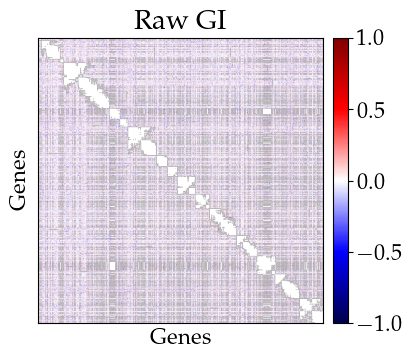

In [5]:
# plot the raw GI network

plot_gi(E, 'Raw GI', save=True)

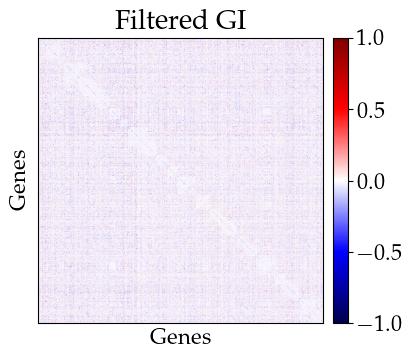

In [6]:
# plot the filtered GI network

plot_gi(E_filtered, 'Filtered GI', save=True)